# Denoiser on real patches

Runs `denoise_patch` on real EMPS patches, not just the hand-checkable toy
case: pick one clean patch, corrupt it with synthetic noise, denoise it
against the rest of the bank, and show the result matches the paper's
claim - the denoiser recovers structure from genuinely similar patches, not
by memorizing the one patch we hid.


## 1. Build a real patch bank

In [1]:
import sys, os
sys.path.append(os.path.join("..", "..", "src"))
import numpy as np
import matplotlib.pyplot as plt

from data.loader import DEV_SOURCE_IDS, load_generator_source
from data.patches import extract_patches

img, source_id = load_generator_source(DEV_SOURCE_IDS[0])
PATCH_SIZE = 8
STRIDE = 4

record = extract_patches(img, PATCH_SIZE, STRIDE)
bank = record.patches.astype(np.float64)
print(f"source: {source_id}, image shape={img.shape}, bank size={len(bank)} patches of {PATCH_SIZE}x{PATCH_SIZE}")


source: 00655d9628, image shape=(515, 512), bank size=16256 patches of 8x8


## 2. Hide one patch, corrupt it with noise

We pick one patch as "ground truth", remove it from the bank (so the
denoiser cannot simply copy it back unchanged), and add synthetic Gaussian
noise to simulate a corrupted patch.

In [2]:
rng = np.random.default_rng(0)

QUERY_INDEX = len(bank) // 2  # an arbitrary patch, not an edge case
ground_truth = bank[QUERY_INDEX].copy()
bank_without_query = np.delete(bank, QUERY_INDEX, axis=0)

NOISE_SIGMA = 20.0
noisy_query = ground_truth + rng.normal(0, NOISE_SIGMA, size=ground_truth.shape)

print(f"ground truth patch value range: [{ground_truth.min():.1f}, {ground_truth.max():.1f}]")
print(f"noisy patch value range: [{noisy_query.min():.1f}, {noisy_query.max():.1f}]")


ground truth patch value range: [146.0, 159.0]
noisy patch value range: [110.5, 191.2]


## 3. Run the denoiser

In [3]:
from models.denoiser import denoise_patch

DENOISE_SIGMA = 30.0
denoised, weights = denoise_patch(noisy_query, bank_without_query, DENOISE_SIGMA)

recovery_error = np.abs(denoised - ground_truth).mean()
noisy_error = np.abs(noisy_query - ground_truth).mean()
print(f"mean abs error vs ground truth - noisy: {noisy_error:.2f}, denoised: {recovery_error:.2f}")


mean abs error vs ground truth - noisy: 14.93, denoised: 2.87


## 4. Visualize: noisy / denoised / ground truth / top-weighted source patches

If the denoiser works, the denoised patch should look closer to the ground
truth than the noisy one, and the top-weighted bank patches should look
visually similar to the ground truth (evidence the weighting is doing
something meaningful, not picking randomly).

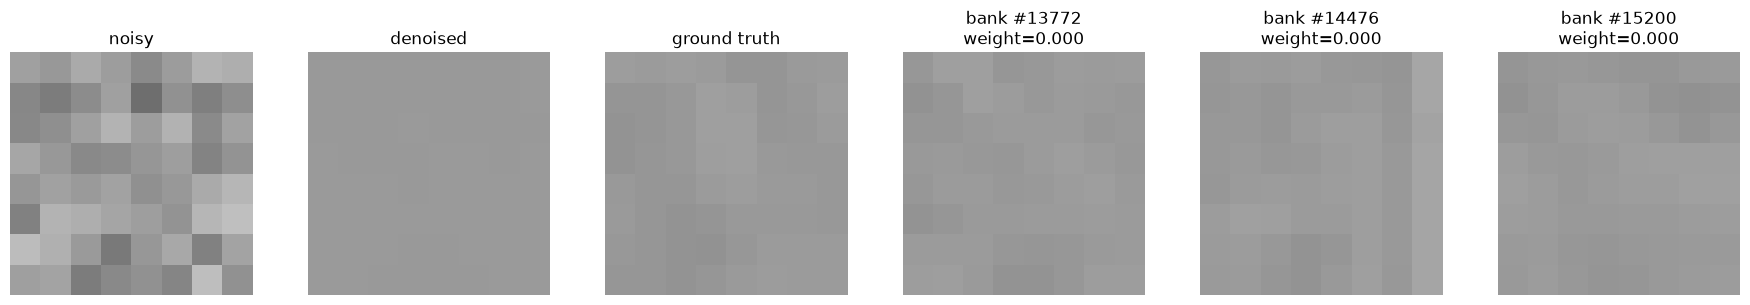

In [4]:
top_k = 3
top_indices = np.argsort(weights)[::-1][:top_k]

fig, axes = plt.subplots(1, 3 + top_k, figsize=(3 * (3 + top_k), 3))
for ax, title, patch in zip(axes[:3], ["noisy", "denoised", "ground truth"], [noisy_query, denoised, ground_truth]):
    ax.imshow(patch, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")

for ax, idx in zip(axes[3:], top_indices):
    ax.imshow(bank_without_query[idx], cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"bank #{idx}\nweight={weights[idx]:.3f}")
    ax.axis("off")

plt.tight_layout()
plt.show()


## Layer 3 status

`denoise_patch` has been verified on: a hand-checkable toy case (pen-and-paper
match), a brute-force cross-check, a numerical-stability edge case (sigma ->
0), and now a real EMPS patch - synthetic noise recovered using genuinely
similar patches from the same source image, not by copying the hidden
ground-truth patch.
